# AI Sentiment vs Shipping Traffic Analysis
Correlating real news sentiment with shipping disruptions

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
%matplotlib inline

plt.rcParams['figure.figsize'] = (20, 10)
plt.rcParams['font.size'] = 11

## Load Shipping Data

In [2]:
arrivals_df = pd.read_csv('Data/Portwatch_Shipment_Data/arrivals-of-ships.csv')
arrivals_df['DateTime'] = pd.to_datetime(arrivals_df['DateTime'])
arrivals_df.set_index('DateTime', inplace=True)
arrivals_df['Total'] = arrivals_df[['Container', 'Dry Bulk', 'General Cargo', 'Roll-on/roll-off', 'Tanker']].sum(axis=1)

arrivals_df.head()

,Container,Dry Bulk,General Cargo,Roll-on/roll-off,Tanker,7-day Moving Average,Prior Year: 7-day Moving Average,Total
DateTime,,,,,,,,
2019-01-01,11,11,3,3,51,NaN,NaN,79
2019-01-02,13,11,0,4,55,NaN,NaN,83
2019-01-03,15,15,5,1,58,NaN,NaN,94
2019-01-04,10,14,2,2,41,NaN,NaN,69
2019-01-05,12,14,3,1,51,NaN,NaN,81


In [3]:
arrivals_df.tail(10)

,Container,Dry Bulk,General Cargo,Roll-on/roll-off,Tanker,7-day Moving Average,Prior Year: 7-day Moving Average,Total
DateTime,,,,,,,,
2026-02-20,16,16,7,2,54,96.571429,86.428571,95
2026-02-21,13,20,4,2,56,94.571429,88.714286,95
2026-02-22,30,24,5,5,73,104.142857,94.571429,137
2026-02-23,14,16,11,4,71,110.000000,94.571429,116
2026-02-24,19,20,4,7,62,114.000000,93.571429,112
2026-02-25,27,20,9,3,61,112.857143,90.571429,120
2026-02-26,15,10,11,3,46,108.571429,83.857143,85
2026-02-27,9,17,4,1,44,105.714286,83.428571,75
2026-02-28,9,17,4,1,59,105.000000,77.428571,90


## Load AI-Analyzed Sentiment Data

In [4]:
sentiment_df = pd.read_csv('Data/crisis_sentiment_analysis.csv')
sentiment_df['date'] = pd.to_datetime(sentiment_df['date'])

sentiment_daily = pd.read_csv('Data/crisis_sentiment_daily.csv')
sentiment_daily['date'] = pd.to_datetime(sentiment_daily['date'])

print(f"Total articles analyzed: {len(sentiment_df)}")
print(f"Date range: {sentiment_df['date'].min()} to {sentiment_df['date'].max()}")
print(f"Crisis events: {sentiment_df['crisis_event'].nunique()}")

sentiment_df.head(10)

Total articles analyzed: 205
Date range: 1920-01-03 00:00:00 to 2026-02-22 00:00:00
Crisis events: 9


,date,title,url,source_name,sentiment,risk_level,confidence,key_factors,used_full_article,article_length,source,crisis_event,crisis_start,crisis_end,expected_sentiment,expected_severity
0,2019-05-12,nan - IRAN (Event: 030),https://www.thetimes.co.uk/edition/world/ships...,GDELT,-0.5,medium,0.70,"military mobilization, sanctions announced, ri...",True,39,GDELT-OpenAI,Gulf of Oman Tanker Attacks,2019-05-12,2019-07-31,High Tension,High
1,2019-05-12,nan - IRAN (Event: 130),http://www.arabtimesonline.com/news/experts-wa...,GDELT,-0.6,high,0.85,"imminent military confrontation indicated, US ...",True,4907,GDELT-OpenAI,Gulf of Oman Tanker Attacks,2019-05-12,2019-07-31,High Tension,High
2,2019-05-12,AUSTRALIA - IRAN (Event: 060),https://www.hellenicshippingnews.com/deficit-o...,GDELT,-0.6,high,0.80,"military mobilization, diplomatic tensions, po...",True,45,GDELT-OpenAI,Gulf of Oman Tanker Attacks,2019-05-12,2019-07-31,High Tension,High
3,2019-05-12,IRAN - nan (Event: 036),https://www.thetimes.co.uk/edition/world/how-o...,GDELT,-0.5,high,0.80,"U.S. military presence with aircraft carriers,...",True,6140,GDELT-OpenAI,Gulf of Oman Tanker Attacks,2019-05-12,2019-07-31,High Tension,High
4,2019-05-06,nan - IRANIAN (Event: 100),http://news.trust.org/item/20190506215752-z35zq,GDELT,-0.5,high,0.70,"military mobilization, serious threats, potent...",True,42,GDELT-OpenAI,Gulf of Oman Tanker Attacks,2019-05-12,2019-07-31,High Tension,High
5,2019-05-06,DEFENSE DEPARTMENT - IRAN (Event: 120),https://www.washingtonpost.com/world/national-...,GDELT,-0.6,high,0.85,"Iran's military mobilization, Increased naval ...",True,54,GDELT-OpenAI,Gulf of Oman Tanker Attacks,2019-05-12,2019-07-31,High Tension,High
6,2019-05-12,IRANIAN - SAUDI (Event: 112),https://www.arabherald.com/news/261086297/trum...,GDELT,-0.7,high,0.85,threats of military action from the US and Ira...,True,4599,GDELT-OpenAI,Gulf of Oman Tanker Attacks,2019-05-12,2019-07-31,High Tension,High
7,2019-05-12,IRAN - NEW YORK (Event: 086),https://abcnews.go.com/Politics/trump-warns-ir...,GDELT,-0.6,high,0.85,U.S. military mobilization with aircraft carri...,True,3496,GDELT-OpenAI,Gulf of Oman Tanker Attacks,2019-05-12,2019-07-31,High Tension,High
8,2019-05-19,nan - IRAN (Event: 036),https://www.arabherald.com/news/261086298/iran...,GDELT,-0.2,medium,0.75,Joint dredging agreement between Iran and Iraq...,True,3336,GDELT-OpenAI,Gulf of Oman Tanker Attacks,2019-05-12,2019-07-31,High Tension,High
9,2019-05-19,BAHRAIN - IRAN (Event: 012),https://www.metro.us/news/the-big-stories/trum...,GDELT,-0.5,high,0.75,"military mobilization, diplomatic tensions, po...",True,43,GDELT-OpenAI,Gulf of Oman Tanker Attacks,2019-05-12,2019-07-31,High Tension,High


In [5]:
sentiment_df.tail(10)

,date,title,url,source_name,sentiment,risk_level,confidence,key_factors,used_full_article,article_length,source,crisis_event,crisis_start,crisis_end,expected_sentiment,expected_severity
195,2025-06-13,CANADA - IRAN (Event: 012),https://www.pentictonherald.ca/news/national_n...,GDELT,-0.600000,high,0.750000,"military mobilization, tensions between Canada...",True,42,GDELT-OpenAI,12-Day Air War (US/ISR vs Iran),2025-06-13,2025-06-24,Open State Warfare,Critical
196,2025-06-13,UNITED KINGDOM - IRAN (Event: 020),https://www.newstalkzb.co.nz/news/world/iran-f...,GDELT,-0.747917,critical,0.800000,Israeli military response involving air strike...,True,8325,GDELT-OpenAI,12-Day Air War (US/ISR vs Iran),2025-06-13,2025-06-24,Open State Warfare,Critical
197,2025-06-13,BRITISH - IRAN (Event: 040),https://www.euronews.com/2025/06/13/trump-says...,GDELT,-0.800000,critical,0.850000,Israeli military strikes on Iran's nuclear fac...,True,5423,GDELT-OpenAI,12-Day Air War (US/ISR vs Iran),2025-06-13,2025-06-24,Open State Warfare,Critical
198,2025-06-13,ENVOY - IRAN (Event: 010),https://www.presstv.ir/Detail/2025/06/13/74977...,GDELT,-0.773109,critical,0.850000,Iran's declaration of the right to self-defens...,True,24115,GDELT-OpenAI,12-Day Air War (US/ISR vs Iran),2025-06-13,2025-06-24,Open State Warfare,Critical
199,2025-06-13,PRESIDENT - IRAN (Event: 040),https://www.thedailystar.net/news/world/iran/n...,GDELT,-0.700000,high,0.850000,"Israeli strikes on Iran, U.S. military involve...",True,3470,GDELT-OpenAI,12-Day Air War (US/ISR vs Iran),2025-06-13,2025-06-24,Open State Warfare,Critical
200,2025-06-13,PRESIDENT - IRAN (Event: 043),https://www.britannica.com:443/topic/Joint-Com...,GDELT,-0.629231,critical,0.812500,"U.S. withdrawal from the JCPOA, U.S.-Iran tens...",True,15178,GDELT-OpenAI,12-Day Air War (US/ISR vs Iran),2025-06-13,2025-06-24,Open State Warfare,Critical
201,2025-02-22,ISRAEL - IRAN (Event: 050),https://www.independent.co.uk/news/world/middl...,GDELT,-0.600000,high,0.750000,"potential return of Taliban to power, impact o...",True,5876,GDELT-OpenAI,Operation Epic Fury / Full Blockade,2026-02-28,2026-03-06,Total Supply Shock,Critical
202,2026-02-22,nan - IRANIAN (Event: 036),https://www.aa.com.tr/en/americas/us-ready-to-...,GDELT,-0.600000,high,0.850000,"US military buildup in the Middle East, Direct...",True,4106,GDELT-OpenAI,Operation Epic Fury / Full Blockade,2026-02-28,2026-03-06,Total Supply Shock,Critical
203,2026-02-22,DAVOS - IRANIAN (Event: 014),https://www.thestar.com.my/news/focus/2026/02/...,GDELT,-0.667000,critical,0.833333,"US strategy of economic warfare, escalating te...",True,8020,GDELT-OpenAI,Operation Epic Fury / Full Blockade,2026-02-28,2026-03-06,Total Supply Shock,Critical
204,2026-02-22,IRAN - UNITED STATES (Event: 046),https://www.columbian.com/news/2026/feb/22/u-s...,GDELT,-0.400000,medium,0.750000,"U.S. military presence in the Middle East, Sta...",True,2207,GDELT-OpenAI,Operation Epic Fury / Full Blockade,2026-02-28,2026-03-06,Total Supply Shock,Critical


In [6]:
sentiment_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   date                205 non-null    datetime64[ns]
 1   title               205 non-null    object        
 2   url                 205 non-null    object        
 3   source_name         205 non-null    object        
 4   sentiment           205 non-null    float64       
 5   risk_level          205 non-null    object        
 6   confidence          205 non-null    float64       
 7   key_factors         204 non-null    object        
 8   used_full_article   205 non-null    bool          
 9   article_length      205 non-null    int64         
 10  source              205 non-null    object        
 11  crisis_event        205 non-null    object        
 12  crisis_start        205 non-null    object        
 13  crisis_end          205 non-null    object        

## Sentiment Statistics by Crisis

In [7]:
sentiment_stats = sentiment_df.groupby('crisis_event').agg({
    'sentiment': ['count', 'mean', 'std', 'min', 'max'],
    'confidence': 'mean',
    'used_full_article': 'sum',
    'article_length': 'mean'
}).round(3)

sentiment_stats.columns = ['Articles', 'Avg_Sentiment', 'Std', 'Min', 'Max', 'Confidence', 'Full_Articles', 'Avg_Length']
sentiment_stats = sentiment_stats.sort_values('Avg_Sentiment')
sentiment_stats

,Articles,Avg_Sentiment,Std,Min,Max,Confidence,Full_Articles,Avg_Length
crisis_event,,,,,,,,
12-Day Air War (US/ISR vs Iran),17,-0.637,0.099,-0.800,-0.500,0.794,17,5205.118
Red Sea / Bab al-Mandab Crisis,25,-0.608,0.149,-0.900,-0.300,0.799,25,4221.280
Iran-Israel Direct Exchange,30,-0.593,0.255,-0.900,0.300,0.813,30,3360.100
US-Iran Escalation (Soleimani),30,-0.580,0.113,-0.800,-0.200,0.798,30,1529.000
Operation Epic Fury / Full Blockade,4,-0.567,0.116,-0.667,-0.400,0.796,4,5052.250
Israel-Iran Naval Incidents,30,-0.533,0.180,-0.700,0.185,0.783,30,3376.533
Gulf of Oman Tanker Attacks,26,-0.531,0.112,-0.700,-0.200,0.771,26,2500.538
"Hormuz Naval ""Inspections"" Warning",20,-0.395,0.345,-0.700,0.500,0.779,20,5291.250
Ukraine War Impact on Energy,23,-0.395,0.253,-0.600,0.400,0.757,23,2803.870


## Merge Sentiment with Shipping Data

In [8]:
merged_df = arrivals_df.reset_index()
merged_df['date'] = merged_df['DateTime'].dt.date
merged_df['date'] = pd.to_datetime(merged_df['date'])

sentiment_daily['date'] = sentiment_daily['date'].dt.date
sentiment_daily['date'] = pd.to_datetime(sentiment_daily['date'])

merged_df = merged_df.merge(
    sentiment_daily[['date', 'sentiment_mean', 'risk_level', 'article_count', 'crisis_event']], 
    on='date', 
    how='left'
)

merged_df.set_index('DateTime', inplace=True)

merged_df[merged_df['sentiment_mean'].notna()].head(10)

,Container,Dry Bulk,General Cargo,Roll-on/roll-off,Tanker,7-day Moving Average,Prior Year: 7-day Moving Average,Total,date,sentiment_mean,risk_level,article_count,crisis_event
DateTime,,,,,,,,,,,,,
2019-01-03,15,15,5,1,58,NaN,NaN,94,2019-01-03,-0.500,high,1.0,US-Iran Escalation (Soleimani)
2019-05-06,13,19,3,5,48,91.714286,NaN,88,2019-05-06,-0.550,high,2.0,Gulf of Oman Tanker Attacks
2019-05-09,17,24,5,1,48,91.428571,NaN,95,2019-05-09,-0.600,high,1.0,Gulf of Oman Tanker Attacks
2019-05-12,13,13,5,2,65,96.000000,NaN,98,2019-05-12,-0.583,high,6.0,Gulf of Oman Tanker Attacks
2019-05-19,9,15,6,2,47,90.571429,NaN,79,2019-05-19,-0.433,high,6.0,Gulf of Oman Tanker Attacks
2019-05-26,17,24,3,1,71,92.142857,NaN,116,2019-05-26,-0.500,high,1.0,Gulf of Oman Tanker Attacks
2019-05-31,17,19,7,0,52,99.714286,NaN,95,2019-05-31,-0.500,high,3.0,Gulf of Oman Tanker Attacks
2019-06-01,15,21,4,2,50,99.428571,NaN,92,2019-06-01,-0.600,high,1.0,Gulf of Oman Tanker Attacks
2019-06-02,15,14,7,1,64,97.285714,NaN,101,2019-06-02,-0.567,high,3.0,Gulf of Oman Tanker Attacks


## Correlation Analysis

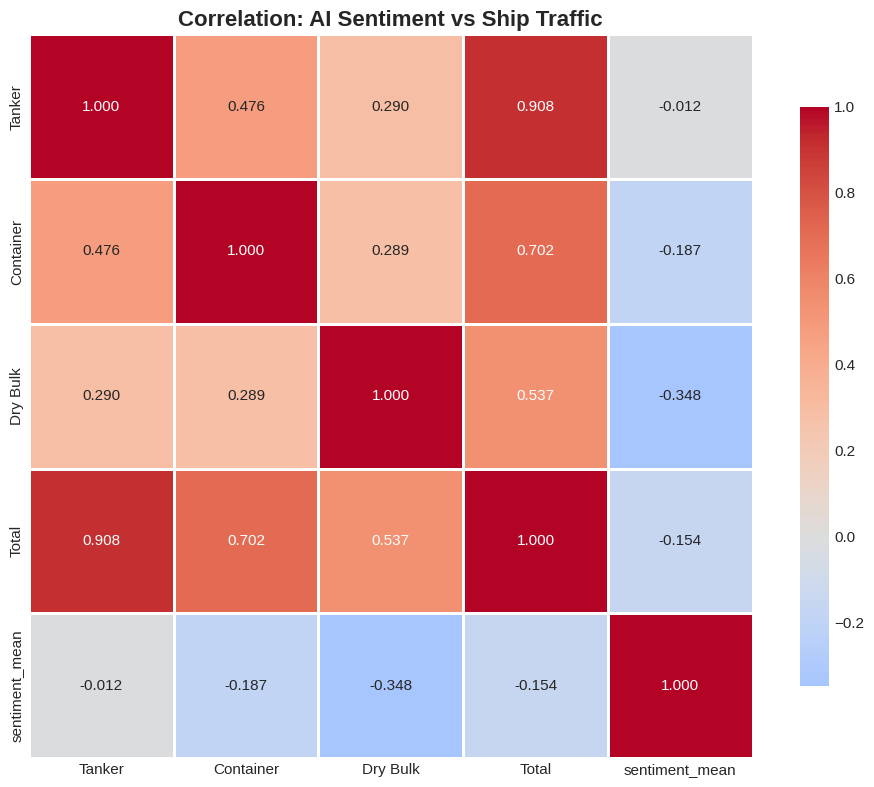

,Tanker,Container,Dry Bulk,Total,sentiment_mean
Tanker,1.000000,0.476119,0.289688,0.907974,-0.012488
Container,0.476119,1.000000,0.289326,0.702239,-0.186530
Dry Bulk,0.289688,0.289326,1.000000,0.536959,-0.347515
Total,0.907974,0.702239,0.536959,1.000000,-0.154339
sentiment_mean,-0.012488,-0.186530,-0.347515,-0.154339,1.000000


In [9]:
correlation_data = merged_df[['Tanker', 'Container', 'Dry Bulk', 'Total', 'sentiment_mean']].dropna()
correlation_matrix = correlation_data.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, fmt='.3f', cmap='coolwarm', center=0, 
            square=True, linewidths=1, cbar_kws={'shrink': 0.8})
plt.title('Correlation: AI Sentiment vs Ship Traffic', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

correlation_matrix

## Tanker Traffic vs AI Sentiment Over Time

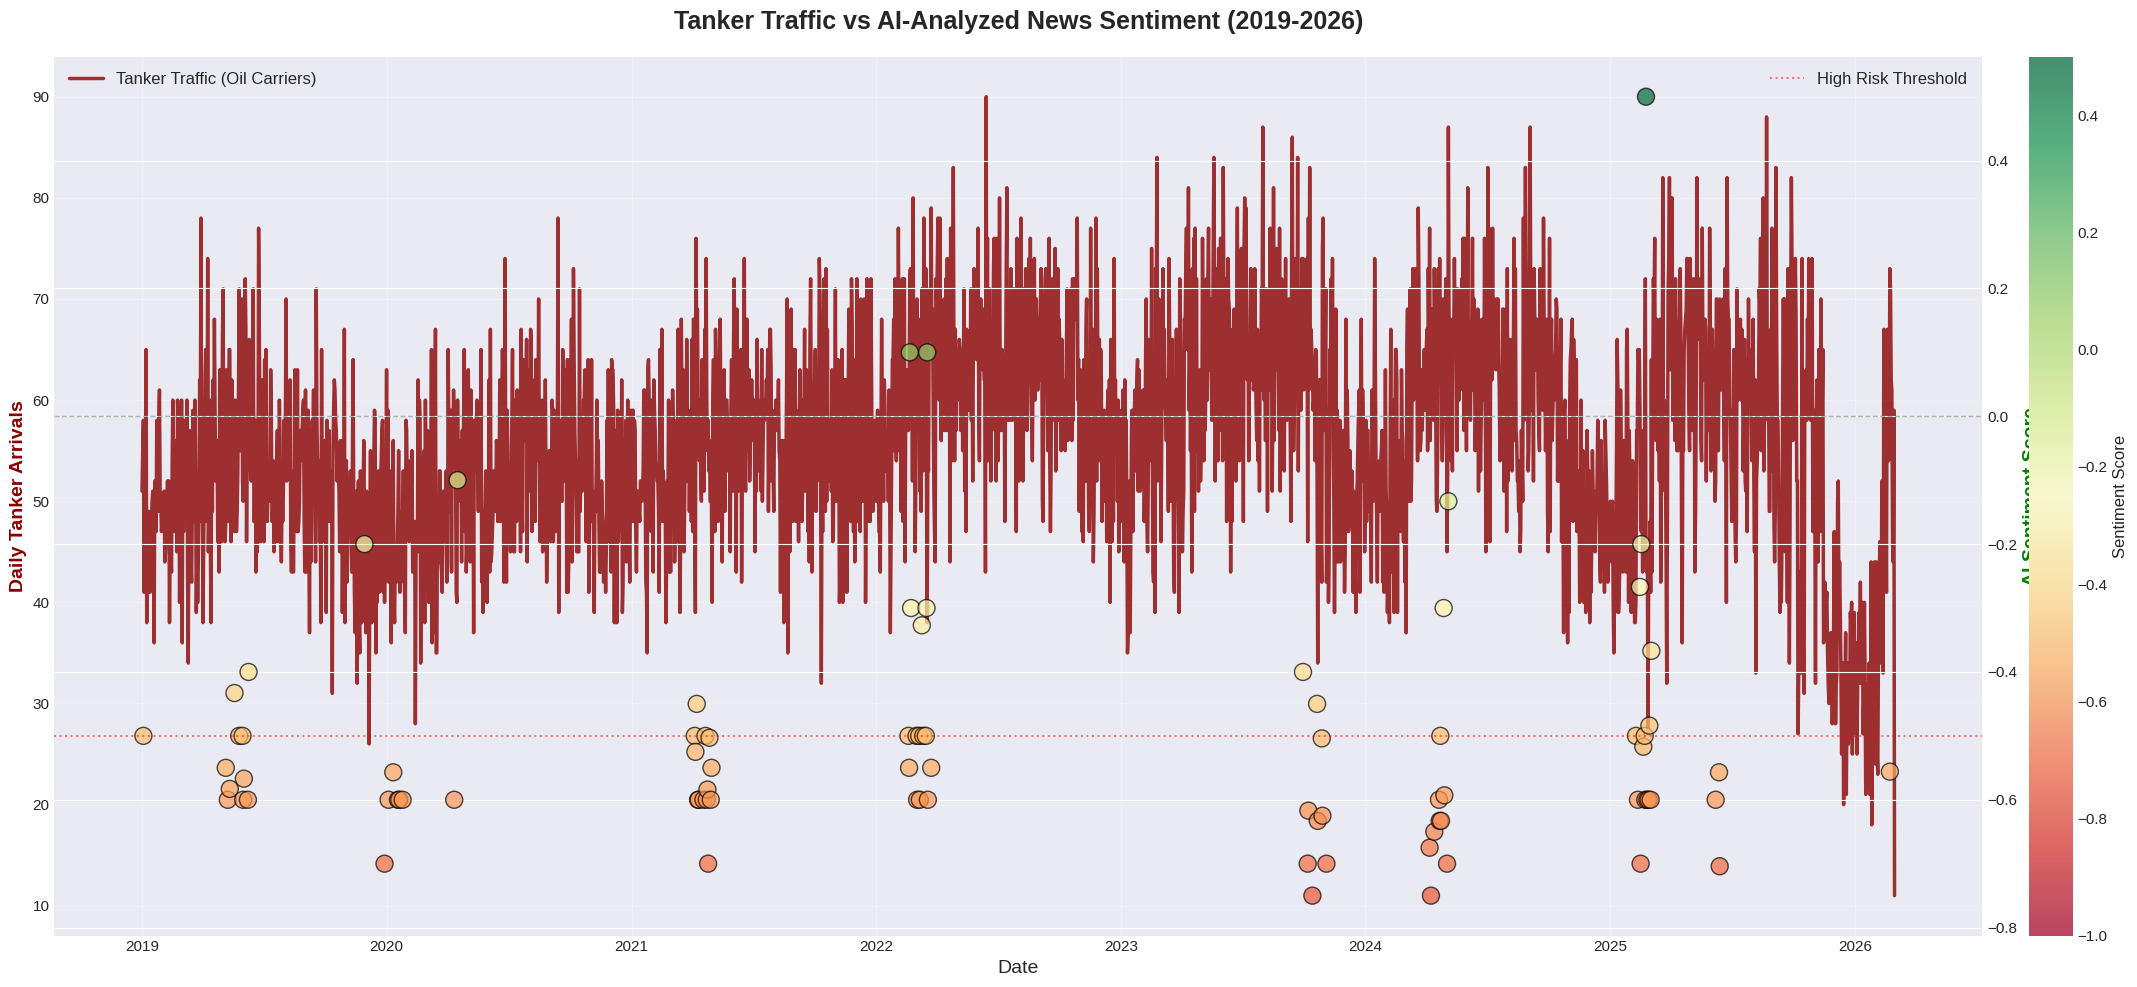

In [10]:
fig, ax1 = plt.subplots(figsize=(24, 10))
ax2 = ax1.twinx()

ax1.plot(merged_df.index, merged_df['Tanker'], linewidth=2.5, color='darkred', 
         label='Tanker Traffic (Oil Carriers)', alpha=0.8, zorder=1)

sentiment_data = merged_df[merged_df['sentiment_mean'].notna()]
scatter = ax2.scatter(sentiment_data.index, sentiment_data['sentiment_mean'], 
                     c=sentiment_data['sentiment_mean'], cmap='RdYlGn', 
                     s=150, alpha=0.7, edgecolors='black', linewidth=1, zorder=2,
                     vmin=-1, vmax=0.5)

ax2.axhline(y=0, color='black', linestyle='--', linewidth=1, alpha=0.3)
ax2.axhline(y=-0.5, color='red', linestyle=':', linewidth=1.5, alpha=0.5, label='High Risk Threshold')

ax1.set_ylabel('Daily Tanker Arrivals', fontsize=14, color='darkred', fontweight='bold')
ax2.set_ylabel('AI Sentiment Score\n(-1=Extreme Negative, +1=Positive)', fontsize=14, color='green', fontweight='bold')
ax1.set_xlabel('Date', fontsize=14)
ax1.set_title('Tanker Traffic vs AI-Analyzed News Sentiment (2019-2026)', fontsize=18, fontweight='bold', pad=20)

ax1.legend(loc='upper left', fontsize=12)
ax2.legend(loc='upper right', fontsize=12)
ax1.grid(True, alpha=0.3)

cbar = plt.colorbar(scatter, ax=ax2, pad=0.02)
cbar.set_label('Sentiment Score', fontsize=12)

plt.tight_layout()
plt.show()

## Total Traffic vs Sentiment

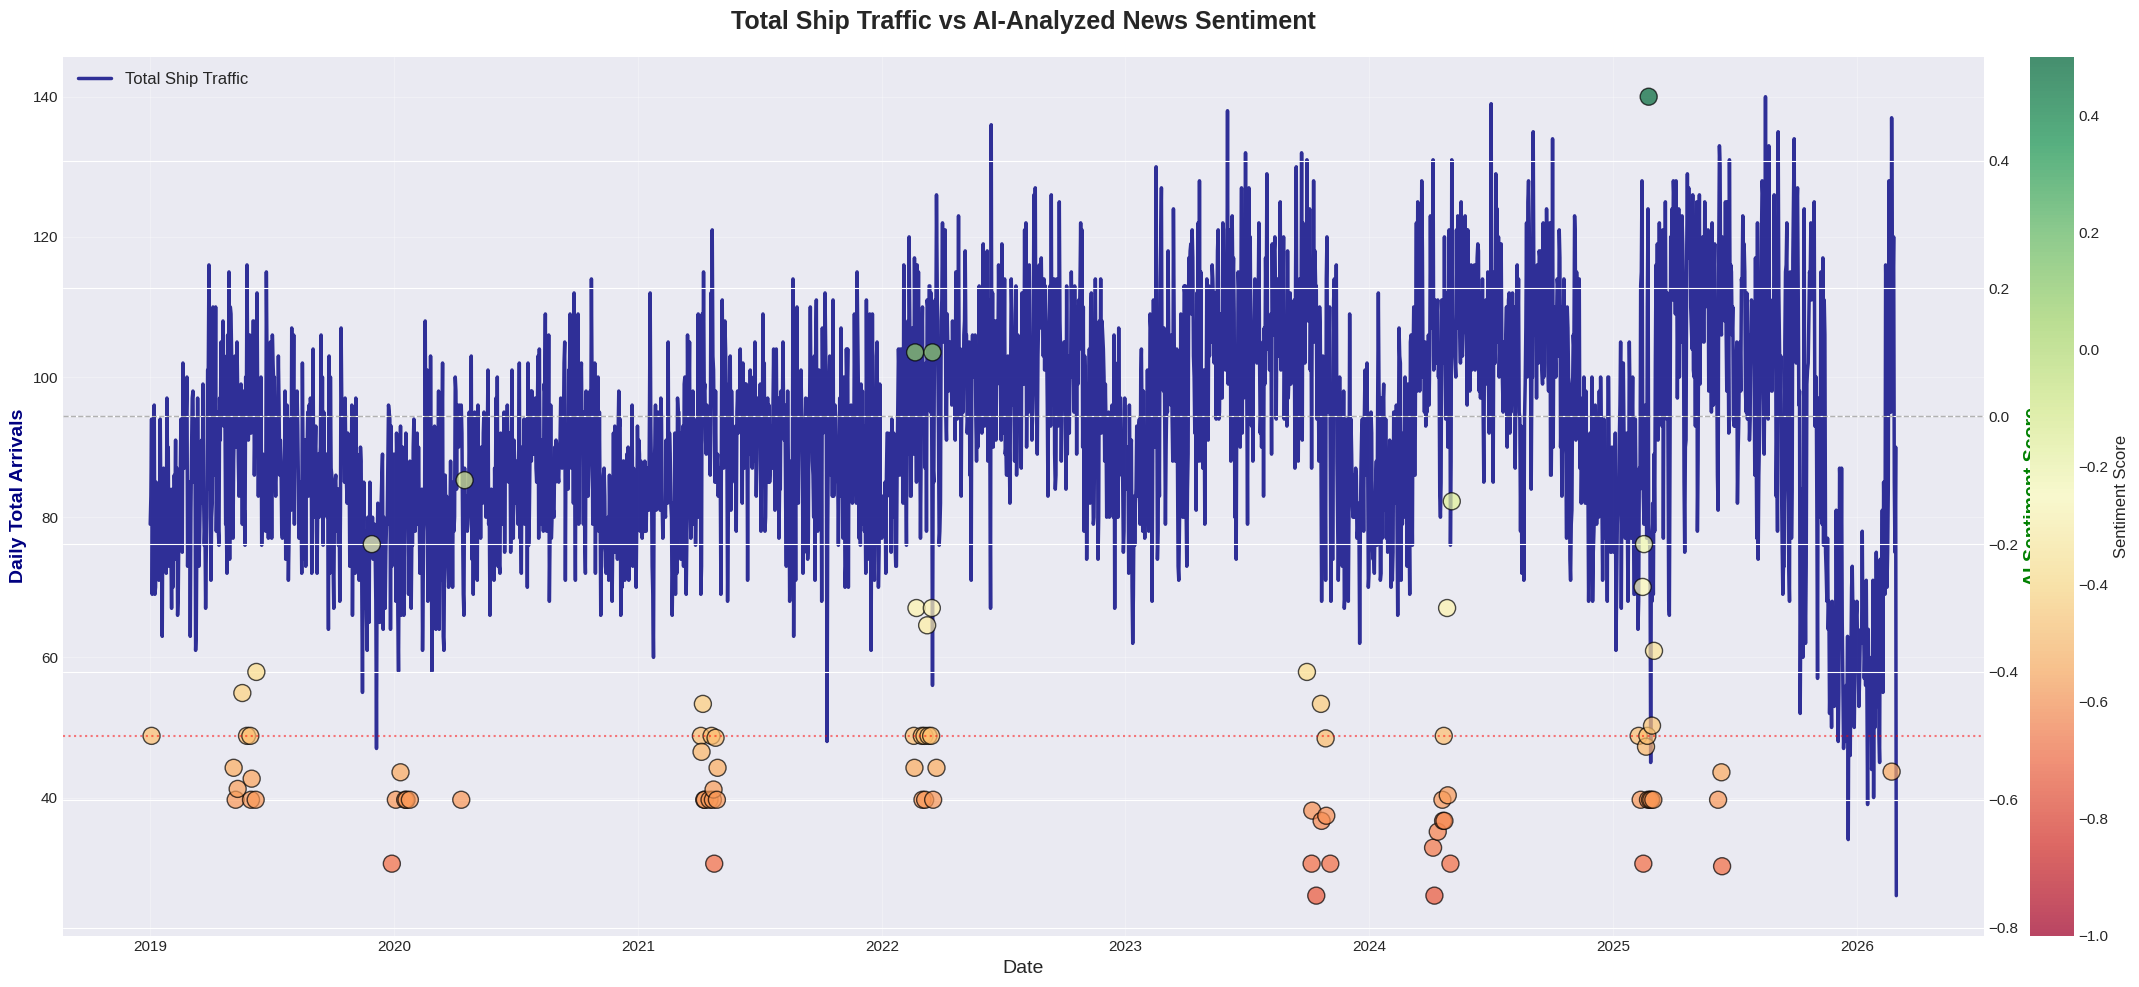

In [11]:
fig, ax1 = plt.subplots(figsize=(24, 10))
ax2 = ax1.twinx()

ax1.plot(merged_df.index, merged_df['Total'], linewidth=2.5, color='navy', 
         label='Total Ship Traffic', alpha=0.8, zorder=1)

sentiment_data = merged_df[merged_df['sentiment_mean'].notna()]
scatter = ax2.scatter(sentiment_data.index, sentiment_data['sentiment_mean'], 
                     c=sentiment_data['sentiment_mean'], cmap='RdYlGn', 
                     s=150, alpha=0.7, edgecolors='black', linewidth=1, zorder=2,
                     vmin=-1, vmax=0.5)

ax2.axhline(y=0, color='black', linestyle='--', linewidth=1, alpha=0.3)
ax2.axhline(y=-0.5, color='red', linestyle=':', linewidth=1.5, alpha=0.5)

ax1.set_ylabel('Daily Total Arrivals', fontsize=14, color='navy', fontweight='bold')
ax2.set_ylabel('AI Sentiment Score', fontsize=14, color='green', fontweight='bold')
ax1.set_xlabel('Date', fontsize=14)
ax1.set_title('Total Ship Traffic vs AI-Analyzed News Sentiment', fontsize=18, fontweight='bold', pad=20)

ax1.legend(loc='upper left', fontsize=12)
ax1.grid(True, alpha=0.3)

cbar = plt.colorbar(scatter, ax=ax2, pad=0.02)
cbar.set_label('Sentiment Score', fontsize=12)

plt.tight_layout()
plt.show()

## Sentiment Scores by Crisis Event

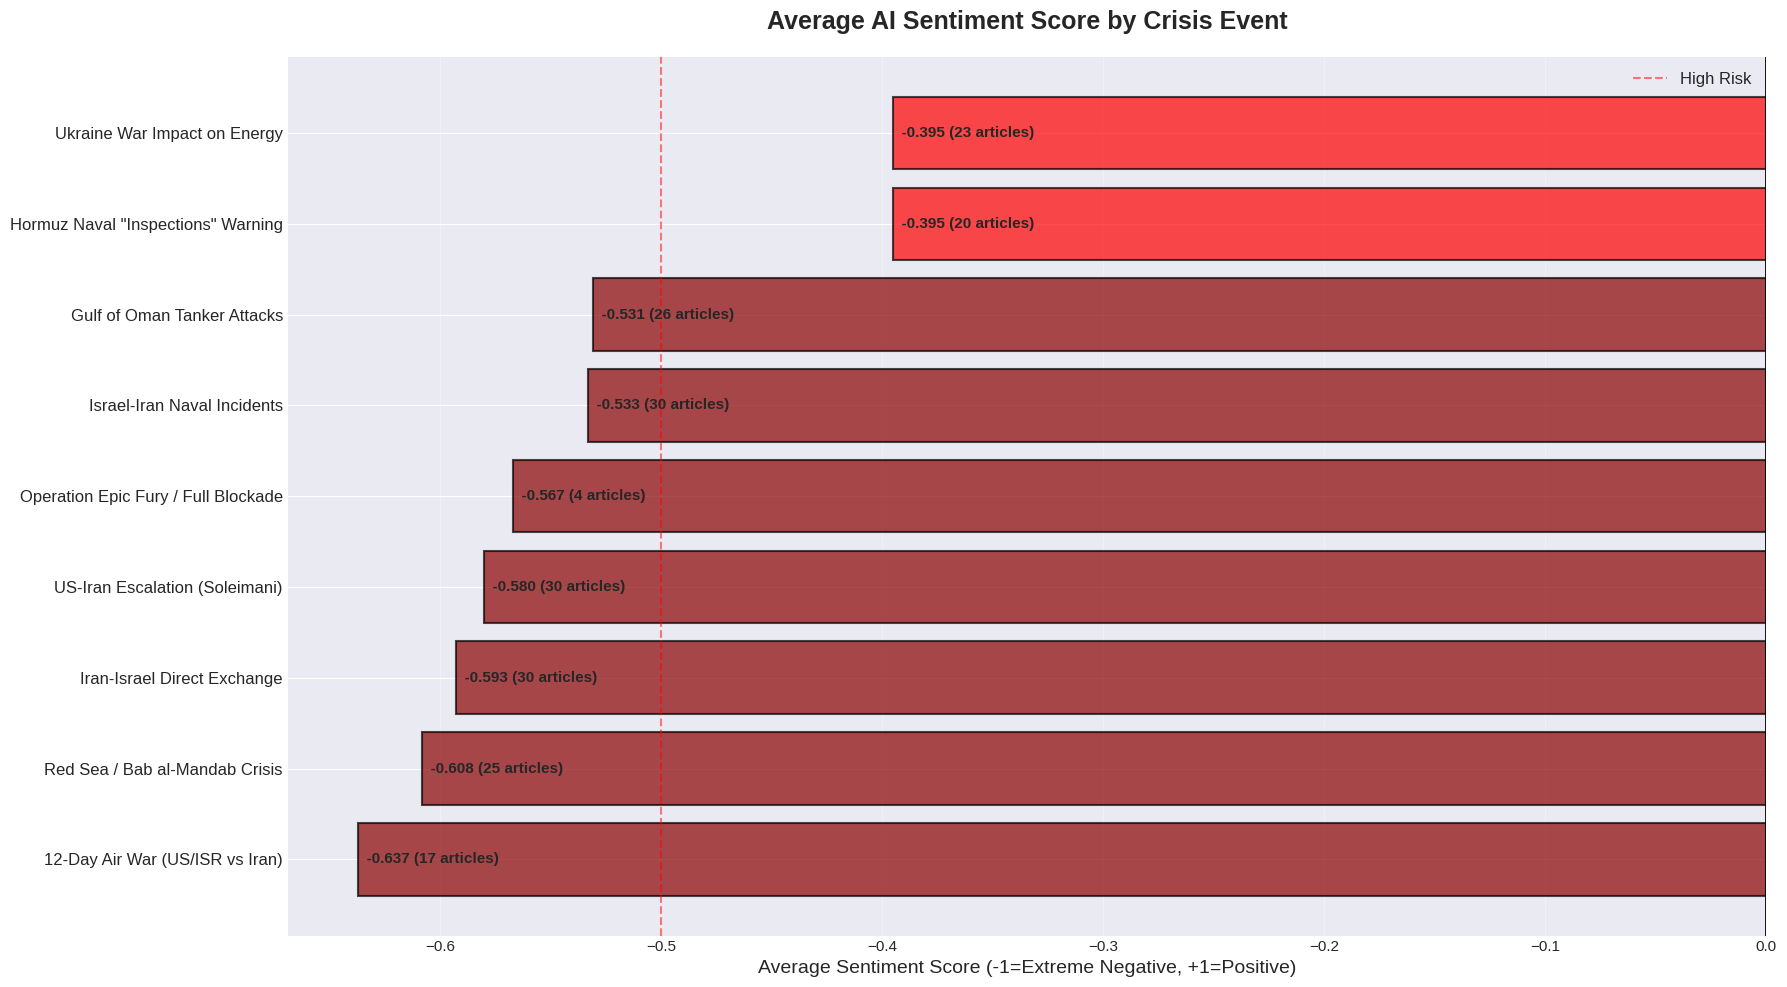

In [12]:
fig, ax = plt.subplots(figsize=(18, 10))

colors = ['darkred' if val < -0.5 else 'red' if val < -0.3 else 'orange' if val < 0 else 'green' 
          for val in sentiment_stats['Avg_Sentiment']]

bars = ax.barh(range(len(sentiment_stats)), sentiment_stats['Avg_Sentiment'], 
               color=colors, alpha=0.7, edgecolor='black', linewidth=1.5)

ax.set_yticks(range(len(sentiment_stats)))
ax.set_yticklabels(sentiment_stats.index, fontsize=12)
ax.axvline(x=0, color='black', linestyle='-', linewidth=2)
ax.axvline(x=-0.5, color='red', linestyle='--', linewidth=1.5, alpha=0.5, label='High Risk')
ax.set_title('Average AI Sentiment Score by Crisis Event', fontsize=18, fontweight='bold', pad=20)
ax.set_xlabel('Average Sentiment Score (-1=Extreme Negative, +1=Positive)', fontsize=14)
ax.grid(True, alpha=0.3, axis='x')
ax.legend(fontsize=12)

for i, (idx, row) in enumerate(sentiment_stats.iterrows()):
    ax.text(row['Avg_Sentiment'], i, 
            f"  {row['Avg_Sentiment']:.3f} ({int(row['Articles'])} articles)", 
            va='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

## Risk Level Distribution by Crisis

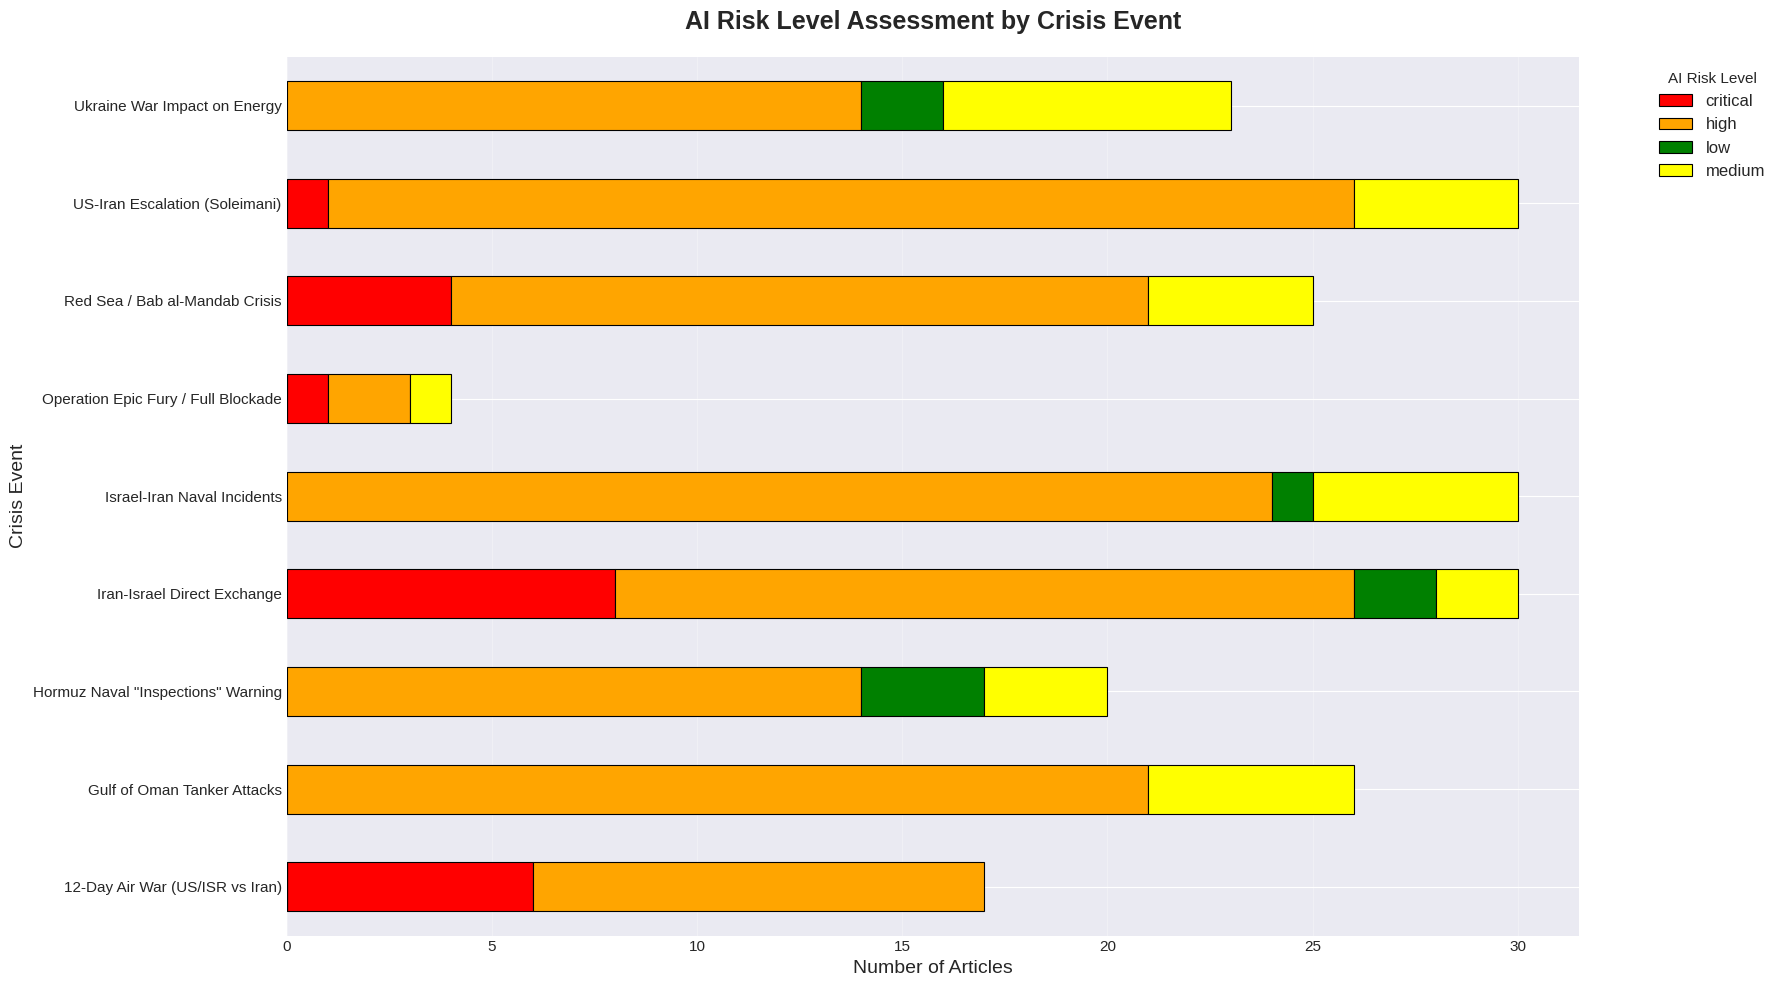

risk_level,critical,high,low,medium
crisis_event,,,,
12-Day Air War (US/ISR vs Iran),6,11,0,0
Gulf of Oman Tanker Attacks,0,21,0,5
"Hormuz Naval ""Inspections"" Warning",0,14,3,3
Iran-Israel Direct Exchange,8,18,2,2
Israel-Iran Naval Incidents,0,24,1,5
Operation Epic Fury / Full Blockade,1,2,0,1
Red Sea / Bab al-Mandab Crisis,4,17,0,4
US-Iran Escalation (Soleimani),1,25,0,4
Ukraine War Impact on Energy,0,14,2,7


In [13]:
risk_distribution = sentiment_df.groupby(['crisis_event', 'risk_level']).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(18, 10))

risk_colors = {'low': 'green', 'medium': 'yellow', 'high': 'orange', 'critical': 'red', 'unknown': 'gray'}
risk_distribution.plot(kind='barh', stacked=True, ax=ax, 
                      color=[risk_colors.get(col, 'gray') for col in risk_distribution.columns],
                      edgecolor='black', linewidth=0.8)

ax.set_title('AI Risk Level Assessment by Crisis Event', fontsize=18, fontweight='bold', pad=20)
ax.set_xlabel('Number of Articles', fontsize=14)
ax.set_ylabel('Crisis Event', fontsize=14)
ax.legend(title='AI Risk Level', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=12)
ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

risk_distribution

## Sentiment Timeline by Event

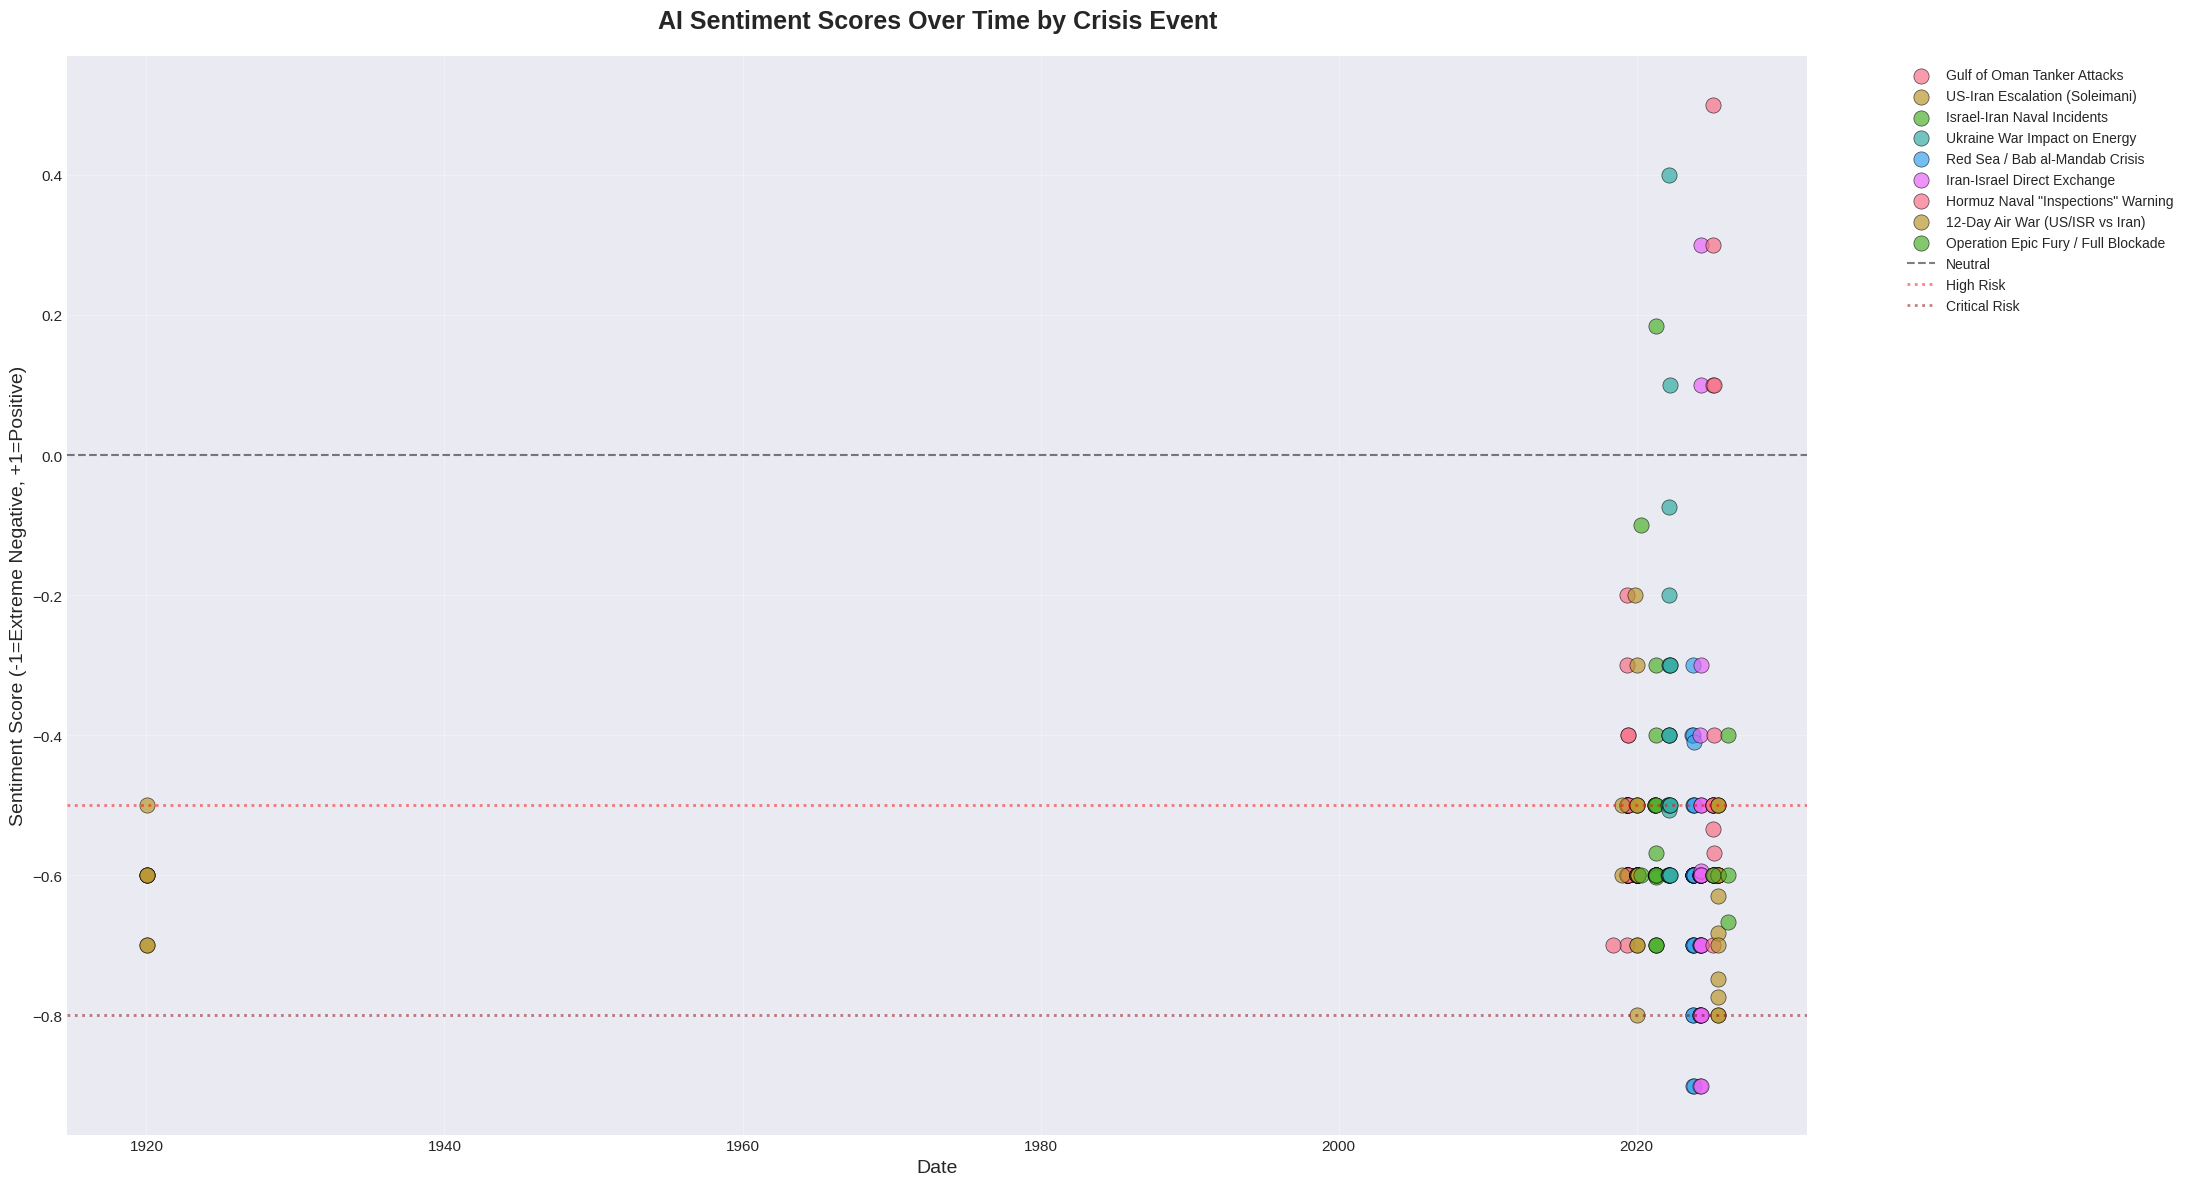

In [14]:
fig, ax = plt.subplots(figsize=(22, 12))

for event in sentiment_df['crisis_event'].unique():
    event_data = sentiment_df[sentiment_df['crisis_event'] == event]
    ax.scatter(event_data['date'], event_data['sentiment'], 
              label=event, alpha=0.7, s=120, edgecolors='black', linewidth=0.5)

ax.axhline(y=0, color='black', linestyle='--', linewidth=1.5, alpha=0.5, label='Neutral')
ax.axhline(y=-0.5, color='red', linestyle=':', linewidth=2, alpha=0.5, label='High Risk')
ax.axhline(y=-0.8, color='darkred', linestyle=':', linewidth=2, alpha=0.5, label='Critical Risk')

ax.set_title('AI Sentiment Scores Over Time by Crisis Event', fontsize=18, fontweight='bold', pad=20)
ax.set_xlabel('Date', fontsize=14)
ax.set_ylabel('Sentiment Score (-1=Extreme Negative, +1=Positive)', fontsize=14)
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Most Negative Articles

In [15]:
most_negative = sentiment_df.nsmallest(15, 'sentiment')[[
    'date', 'crisis_event', 'title', 'sentiment', 'risk_level', 'confidence', 'key_factors'
]]
most_negative

,date,crisis_event,title,sentiment,risk_level,confidence,key_factors
110,2023-10-14,Red Sea / Bab al-Mandab Crisis,IRANIAN - ISRAELI (Event: 190),-0.900000,critical,0.90,Israeli military operations causing high civil...
133,2023-10-29,Red Sea / Bab al-Mandab Crisis,IRAN - IRANIAN (Event: 130),-0.900000,critical,0.85,large-scale military operations involving Isra...
140,2024-04-13,Iran-Israel Direct Exchange,nan - IRAN (Event: 014),-0.900000,critical,0.95,Iran's direct military attack on Israel using ...
160,2024-05-02,Iran-Israel Direct Exchange,IRAN - nan (Event: 194),-0.900000,critical,0.85,"actual missile attacks from Iran on Israel, in..."
45,2020-01-11,US-Iran Escalation (Soleimani),UNITED KINGDOM - IRAN (Event: 084),-0.800000,critical,0.90,"Potential for military conflict escalation, Th..."
122,2023-10-22,Red Sea / Bab al-Mandab Crisis,DEFENSE SECRETARY - IRAN (Event: 010),-0.800000,critical,0.85,"Israeli air strikes on Gaza and Lebanon, Escal..."
124,2023-10-22,Red Sea / Bab al-Mandab Crisis,IRANIAN - ISRAELI (Event: 040),-0.800000,critical,0.85,"ongoing military actions in Gaza and Israel, h..."
135,2024-04-08,Iran-Israel Direct Exchange,IRAN - PALESTINIAN (Event: 051),-0.800000,critical,0.85,"Israeli airstrikes in southern Lebanon, Hezbol..."
139,2024-04-06,Iran-Israel Direct Exchange,ISRAEL - IRANIAN (Event: 020),-0.800000,critical,0.85,Iran launches dozens of drones and missiles at...
141,2024-04-13,Iran-Israel Direct Exchange,nan - IRAN (Event: 042),-0.800000,critical,0.90,Iran launches over 100 drones and missiles tow...


## Impact Analysis: Sentiment vs Traffic Drop

In [16]:
impact_analysis = []

for event in sentiment_df['crisis_event'].unique():
    event_sentiment = sentiment_df[sentiment_df['crisis_event'] == event]
    
    if len(event_sentiment) > 0:
        start_date = event_sentiment['date'].min()
        end_date = event_sentiment['date'].max()
        
        event_traffic = merged_df[(merged_df.index >= start_date) & (merged_df.index <= end_date)]
        
        pre_event_start = start_date - timedelta(days=30)
        pre_event_traffic = merged_df[(merged_df.index >= pre_event_start) & (merged_df.index < start_date)]
        
        if len(event_traffic) > 0 and len(pre_event_traffic) > 0:
            impact_analysis.append({
                'Event': event,
                'Avg_Sentiment': event_sentiment['sentiment'].mean(),
                'Min_Sentiment': event_sentiment['sentiment'].min(),
                'Pre_Tanker_Avg': pre_event_traffic['Tanker'].mean(),
                'Event_Tanker_Avg': event_traffic['Tanker'].mean(),
                'Tanker_Drop_Pct': ((event_traffic['Tanker'].mean() - pre_event_traffic['Tanker'].mean()) / 
                                   pre_event_traffic['Tanker'].mean() * 100),
                'Pre_Total_Avg': pre_event_traffic['Total'].mean(),
                'Event_Total_Avg': event_traffic['Total'].mean(),
                'Total_Drop_Pct': ((event_traffic['Total'].mean() - pre_event_traffic['Total'].mean()) / 
                                  pre_event_traffic['Total'].mean() * 100)
            })

impact_df = pd.DataFrame(impact_analysis).round(2)
impact_df = impact_df.sort_values('Avg_Sentiment')
impact_df

,Event,Avg_Sentiment,Min_Sentiment,Pre_Tanker_Avg,Event_Tanker_Avg,Tanker_Drop_Pct,Pre_Total_Avg,Event_Total_Avg,Total_Drop_Pct
5,12-Day Air War (US/ISR vs Iran),-0.64,-0.80,62.93,64.14,1.92,110.10,113.71,3.28
2,Red Sea / Bab al-Mandab Crisis,-0.61,-0.90,65.03,62.17,-4.41,106.70,102.78,-3.68
3,Iran-Israel Direct Exchange,-0.59,-0.90,62.93,63.07,0.22,106.30,103.93,-2.23
6,Operation Epic Fury / Full Blockade,-0.57,-0.67,51.50,52.94,2.80,88.43,92.91,5.07
0,Israel-Iran Naval Incidents,-0.53,-0.70,50.00,53.17,6.34,82.80,86.52,4.50
4,"Hormuz Naval ""Inspections"" Warning",-0.40,-0.70,50.40,51.12,1.44,85.90,87.17,1.47
1,Ukraine War Impact on Energy,-0.39,-0.60,58.70,62.20,5.96,94.57,98.74,4.42


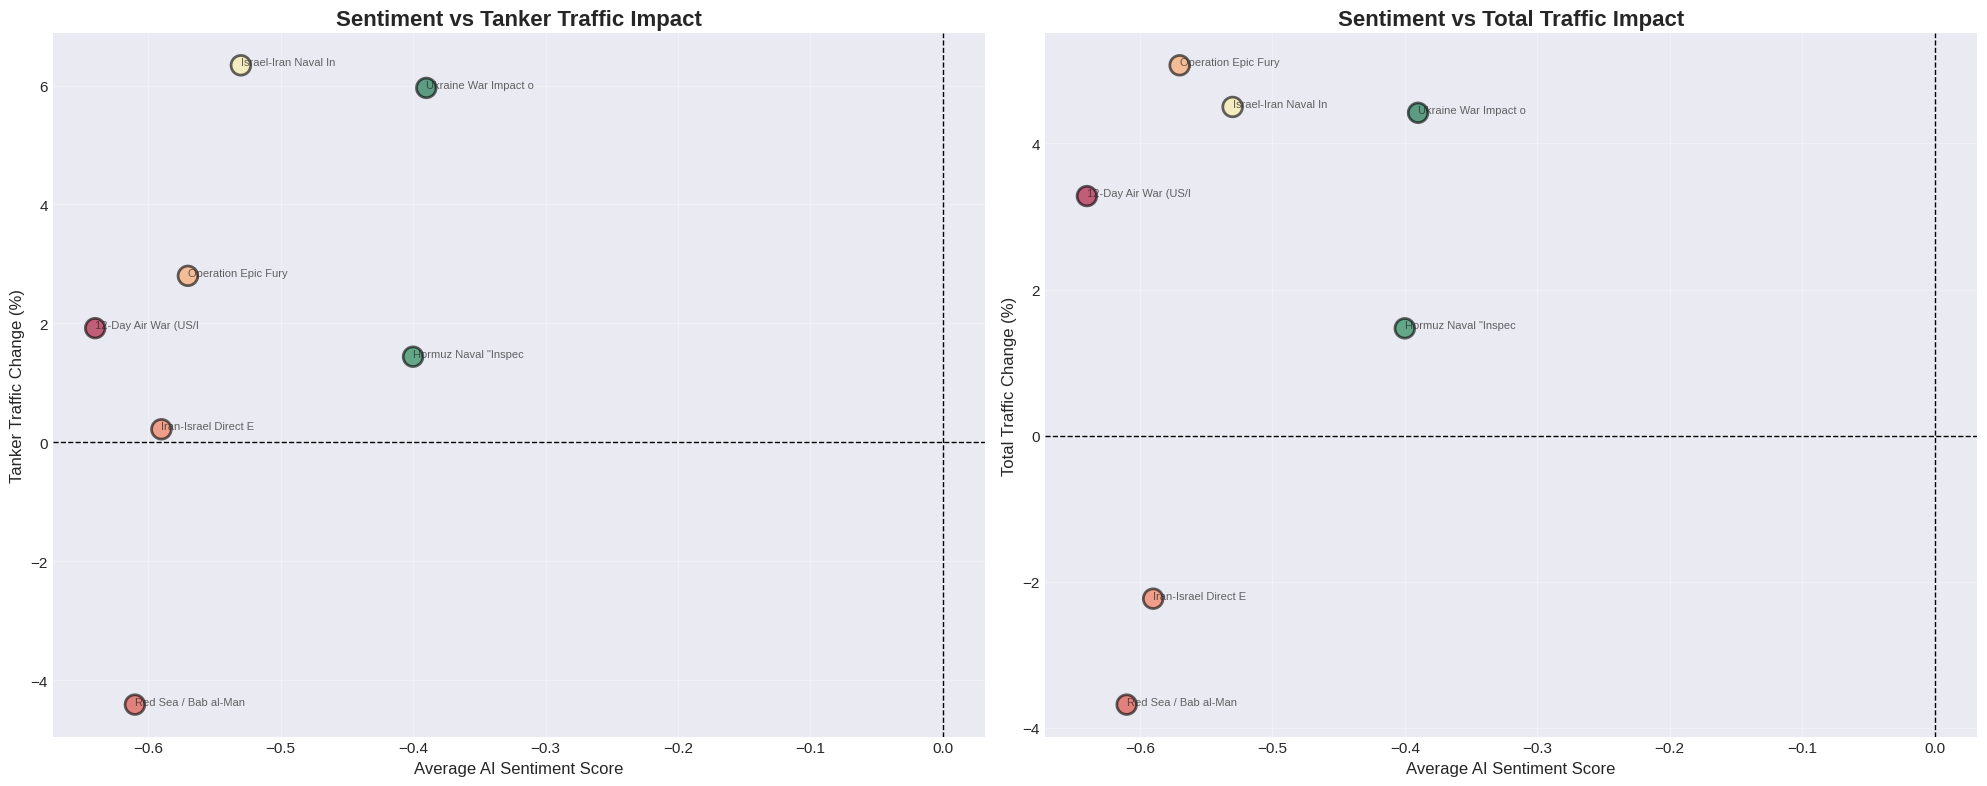

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

axes[0].scatter(impact_df['Avg_Sentiment'], impact_df['Tanker_Drop_Pct'], 
               s=200, alpha=0.6, c=impact_df['Avg_Sentiment'], cmap='RdYlGn', 
               edgecolors='black', linewidth=2)
axes[0].axhline(y=0, color='black', linestyle='--', linewidth=1)
axes[0].axvline(x=0, color='black', linestyle='--', linewidth=1)
axes[0].set_title('Sentiment vs Tanker Traffic Impact', fontsize=16, fontweight='bold')
axes[0].set_xlabel('Average AI Sentiment Score', fontsize=12)
axes[0].set_ylabel('Tanker Traffic Change (%)', fontsize=12)
axes[0].grid(True, alpha=0.3)

for _, row in impact_df.iterrows():
    axes[0].annotate(row['Event'][:20], (row['Avg_Sentiment'], row['Tanker_Drop_Pct']), 
                    fontsize=8, alpha=0.7)

axes[1].scatter(impact_df['Avg_Sentiment'], impact_df['Total_Drop_Pct'], 
               s=200, alpha=0.6, c=impact_df['Avg_Sentiment'], cmap='RdYlGn', 
               edgecolors='black', linewidth=2)
axes[1].axhline(y=0, color='black', linestyle='--', linewidth=1)
axes[1].axvline(x=0, color='black', linestyle='--', linewidth=1)
axes[1].set_title('Sentiment vs Total Traffic Impact', fontsize=16, fontweight='bold')
axes[1].set_xlabel('Average AI Sentiment Score', fontsize=12)
axes[1].set_ylabel('Total Traffic Change (%)', fontsize=12)
axes[1].grid(True, alpha=0.3)

for _, row in impact_df.iterrows():
    axes[1].annotate(row['Event'][:20], (row['Avg_Sentiment'], row['Total_Drop_Pct']), 
                    fontsize=8, alpha=0.7)

plt.tight_layout()
plt.show()

## Key Findings

In [19]:
findings = {
    'Total Articles Analyzed': len(sentiment_df),
    'Crisis Events Covered': sentiment_df['crisis_event'].nunique(),
    'Date Range': f"{sentiment_df['date'].min().date()} to {sentiment_df['date'].max().date()}",
    'Most Negative Event': sentiment_stats.index[0],
    'Most Negative Avg Sentiment': sentiment_stats['Avg_Sentiment'].iloc[0],
    'Correlation (Sentiment vs Tanker)': correlation_matrix.loc['sentiment_mean', 'Tanker'].round(3),
    'Correlation (Sentiment vs Total)': correlation_matrix.loc['sentiment_mean', 'Total'].round(3),
    'Avg Confidence Score': sentiment_df['confidence'].mean().round(3),
    'Full Articles Analyzed': sentiment_df['used_full_article'].sum()
}

findings_df = pd.DataFrame([findings]).T
findings_df.columns = ['Value']
findings_df

,Value
Total Articles Analyzed,205
Crisis Events Covered,9
Date Range,1920-01-03 to 2026-02-22
Most Negative Event,12-Day Air War (US/ISR vs Iran)
Most Negative Avg Sentiment,-0.637
Correlation (Sentiment vs Tanker),-0.012
Correlation (Sentiment vs Total),-0.154
Avg Confidence Score,0.788
Full Articles Analyzed,205
